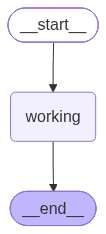

In [1]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from pydantic_ai import Agent
from typing import TypedDict, Literal


class InterviewQuestion(BaseModel):
    original_question: str
    interview_question: str
    expected_answer: str
    evaluation_criteria: list[str] = Field(default_factory=list)
    follow_up_question: list[str] = Field(default_factory=list)
    
class AnswerEvaluation(BaseModel):
    question: str
    user_answer: str
    score: int = Field(ge=0, le=10)
    
    weaknesses: list[str] = Field(default_factory=list)
    strengths: list[str] = Field(default_factory=list)
    
    feedback: str
    
class InterviewConversationState(TypedDict):
    role: str
    experience_level: str
    interview_type: str
    input_questions: list[str]
    prepared_questions: list[InterviewQuestion]
    current_question_index: int
    current_question: InterviewQuestion | None
    current_answer: str
    evaluations: list[AnswerEvaluation]
    conversation_history: list[dict[str, str]]
    status: Literal[
        "preparing",
        "asking",
        "listening",
        "evaluating",
        "follow_up",
        "completed",
    ]
    overall_score: float | None
    final_feedback: str | None
    
    
    


def working(state: InterviewConversationState):
    print("working!!!")
    


graph = StateGraph(InterviewConversationState)


graph.add_node("working", working)


graph.add_edge(START, "working")
graph.add_edge("working", END)

workflow = graph.compile()

from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())